<a href="https://colab.research.google.com/github/pentonfreak/CART498-GenAI/blob/main/CART489_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can install Python libraries in Google Colab using the `pip` package installer. Just prefix the `pip install` command with an exclamation mark `!`.

In [ ]:
# Example: Install the pandas library
!pip install pandas

In [ ]:
# Install required libraries
!pip install diffusers torch

In [ ]:
from huggingface_hub import login
from google.colab import userdata

# Retrieve your HF token from Colab's secrets manager
hf_token = userdata.get('CART489')

if hf_token:
    login(token=hf_token)
    print("Successfully logged in to Hugging Face Hub.")
else:
    print("Hugging Face token not found. Please add it to Colab secrets as 'HF_TOKEN'.")

Successfully logged in to Hugging Face Hub.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (96 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', distressed textures , cut - and - paste , cosmic background , witty , highly detailed mixed - media .']
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (96 > 77). Running this sequence through the model will result in 

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


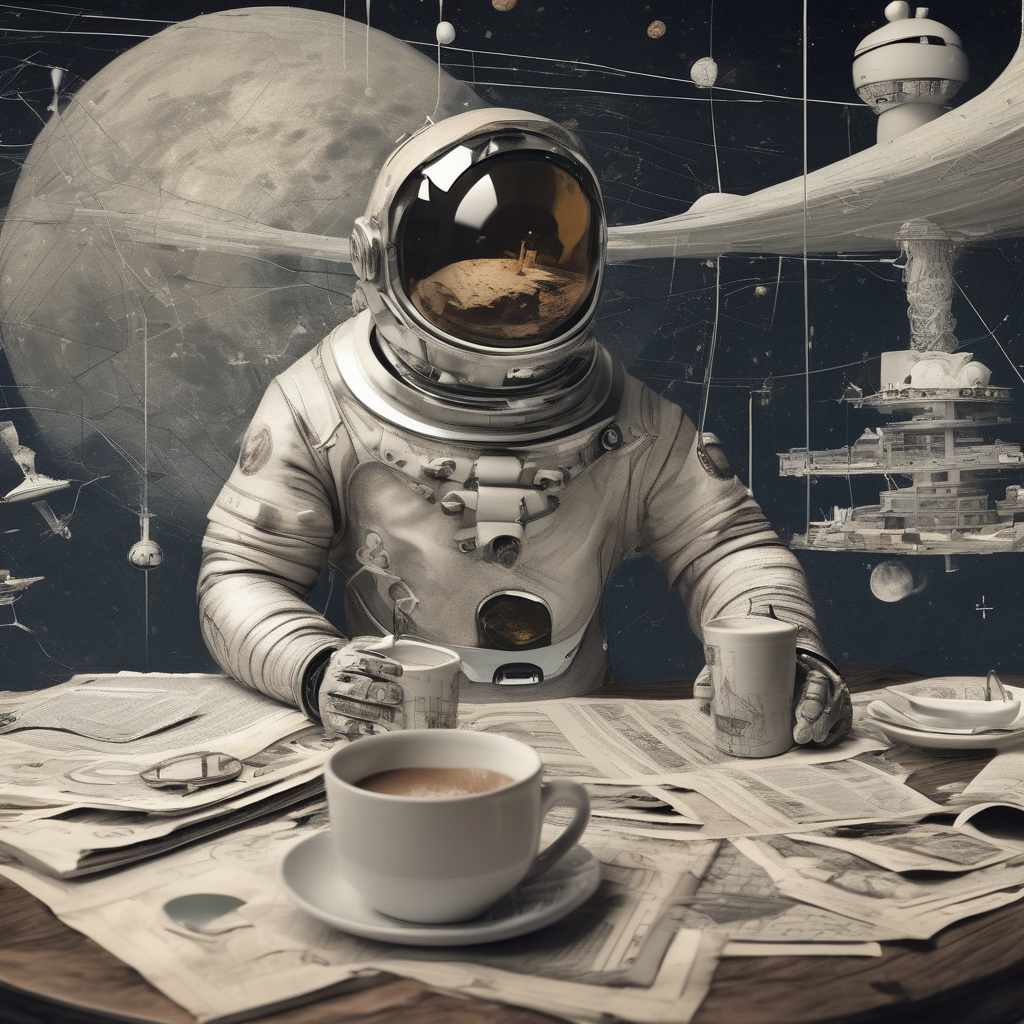

In [ ]:
from diffusers import StableDiffusionXLPipeline
import torch

# Load the Stable Diffusion pipeline. This will download the model weights the first time.
pipeline = StableDiffusionXLPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", dtype=torch.float16)

# Move the pipeline to GPU if available
if torch.cuda.is_available():
    pipeline.to("cuda")

# Define your prompt
# prompt = "A surreal and humorous sci-fi collage of a lone astronaut sitting at a tiny vintage café table on the surface of the Moon, casually drinking Vietnamese phin coffee. A massive futuristic spaceship is parked behind him like a badly parked car, with one landing leg resting on a giant coffee cup. The Moon is covered with scattered newspaper fragments, technical diagrams, wires, geometric shapes, and vintage mechanical parts. The astronaut looks completely relaxed and slightly confused, as if having coffee during a space mission is perfectly normal. Dreamlike composition, absurd scale, Dadaist collage aesthetics, surrealism, vintage science-fiction imagery, distressed paper textures, cut-and-paste photography, scientific diagrams, dramatic cosmic background, witty visual humor, highly detailed mixed-media collage."

prompt = "Surreal sci-fi collage: Lone astronaut drinks phin coffee at a moon-café table. A tilted spaceship is badly parked behind him, leg stuck in a giant coffee cup. Moon surface covered with newspapers, diagrams, wires, geometric shapes, vintage mechanical parts. Astronaut remains calm amidst falling ship. Dreamlike, absurd, Dadaist, vintage sci-fi aesthetic, distressed textures, cut-and-paste, cosmic background, witty, highly detailed mixed-media."


negative_prompt = """blurry, lowres, watermark, text, deformed faces, extra limbs,
bad anatomy, extra fingers, cartoon, illustration, oversaturated"""

# Generate an image
image = pipeline(prompt).images[0]

# Display the image
image

In [ ]:
import os

# Define an output directory if it doesn't exist
output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

# Save the generated image to a file
image_filename = os.path.join(output_dir, "generated_collage1.png")
image.save(image_filename)
print(f"Image saved as {image_filename}")

Image saved as generated_images/generated_collage1.png


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

To authenticate requests to the Hugging Face Hub, you need an API token. You can generate one from your [Hugging Face profile settings](https://huggingface.co/settings/tokens).

Once you have the token, store it securely in Colab's secrets manager (the '🔑' icon in the left panel) under the name `HF_TOKEN`. Then, you can use the `huggingface_hub` library to log in.

In [ ]:
!pip install -q diffusers transformers accelerate torch safetensors

import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

prompts = [
    """A surreal and humorous sci-fi collage of a lone astronaut sitting at a tiny vintage café table on the surface of the Moon, casually drinking Vietnamese phin coffee. The U.S.S. Enterprise parked behind him like a badly parked car in a space port. The moon is covered with 1950s newspapers shreds, mini figures of Space Marines, wire, and mechanical parts. The astronaut looks completely normal and relax, as if having coffee during space walks is perfectly normal. High contrast lighting, dreamlike composition, Dadaist collage style, surrealism, mysterious cosmic background and comical visual humor...""",

    """A surreal sci-fi collage of the same astronaut calmly drinking Vietnamese phin coffee on the Moon. The U.S.S. Enterprise is badly parked behind him, tilted and partly crashed. The Moon is covered with 1950s newspaper shreds, Space Marine miniatures, wires, and mechanical parts. Space Marines desperately repair the ship while the astronaut ignores everything. High contrast, Dadaist collage, surrealism, mysterious cosmic background, absurd humor...""",

    """A surreal sci-fi collage of the same astronaut calmly drinking Vietnamese phin coffee on the Moon while everything has gone wrong. The U.S.S. Enterprise is crashed and buried behind him, surrounded by tangled wires, broken machinery, 1950s newspaper shreds, and hundreds of Space Marine miniatures desperately trying to repair it. The astronaut remains completely relaxed, reading a newspaper. High contrast, Dadaist collage, surrealism, chaotic cosmic background, absurd humor..."""
]

for i, prompt in enumerate(prompts, start=1):

    image = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]

    image.save(f"A1_0{i}.jpg", quality=95)

    print(f"Generated A1_0{i}.jpg")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (123 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['and mechanical parts . the astronaut looks completely normal and relax , as if having coffee during space walks is perfectly normal . high contrast lighting , dreamlike composition , dadaist collage style , surrealism , mysterious cosmic background and comical visual humor ...']


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['reading a newspaper . high contrast , dadaist collage , surrealism , chaotic cosmic background , absurd humor ...']


Generated A1_02.jpg


  0%|          | 0/30 [00:00<?, ?it/s]

Generated A1_03.jpg


In [ ]:
import os
import shutil

output_dir = "generated_images"

# Create the output directory if it doesn't exist (already handled, but good to be robust)
os.makedirs(output_dir, exist_ok=True)

for i in range(1, 4):
    source_filename = f"A1_0{i}.jpg"
    destination_filename = os.path.join(output_dir, f"Gen_collage{i}.png")
    try:
        shutil.move(source_filename, destination_filename)
        print(f"Moved and renamed {source_filename} to {destination_filename}")
    except FileNotFoundError:
        print(f"Error: {source_filename} not found. Skipping.")

Error: A1_01.jpg not found. Skipping.
Error: A1_02.jpg not found. Skipping.
Error: A1_03.jpg not found. Skipping.
